# Task : Determine the eligibility for granting Homeloan .
objectives
>- To understand the patterns in the data 
>- How to handle the categorical features 
>- How to deal with missing data 
>- Feature Engineering 
>- Finding the most important features while taking the decision of granting a loan application
>- understanding the normalization and standardisation of the data 


#### Import Required Libraries 

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score  

#### Load the Dataset

In [4]:
data = pd.read_csv('realistic_home_loan_dataset_700.csv')

#### Basic data understanding 

In [5]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,Male,Yes,3+,Not Graduate,No,2488,1724,85.0,180.0,NaN,Urban,Y
1,LP100001,Female,Yes,0,Not Graduate,No,3671,1277,98.0,NaN,1.0,Rural,Y
2,LP100002,NaN,Yes,0,Not Graduate,NaN,2901,1354,132.0,360.0,1.0,Rural,Y
3,LP100003,Male,Yes,1,Not Graduate,Yes,1824,2745,115.0,360.0,1.0,Urban,Y
4,LP100004,Male,Yes,2,Graduate,No,5223,1325,145.0,240.0,1.0,Semiurban,Y


In [6]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
695,LP100695,Male,No,1,Graduate,No,4091,0,104.0,360.0,1.0,Semiurban,Y
696,LP100696,Male,Yes,0,Not Graduate,Yes,3014,1255,74.0,360.0,1.0,Urban,Y
697,LP100697,Male,Yes,1,Not Graduate,No,1476,2579,70.0,180.0,1.0,Semiurban,Y
698,LP100698,Male,Yes,3+,Graduate,No,1821,2311,67.0,240.0,1.0,Semiurban,Y
699,LP100699,Male,No,0,Graduate,NaN,3292,0,83.0,180.0,NaN,Urban,Y


In [7]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [8]:
data.shape

(700, 13)

#### There are 700 rows and 13 columns present in the data set 

In [9]:
data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            700 non-null    object 
 1   Gender             665 non-null    object 
 2   Married            665 non-null    object 
 3   Dependents         665 non-null    object 
 4   Education          700 non-null    object 
 5   Self_Employed      665 non-null    object 
 6   ApplicantIncome    700 non-null    int64  
 7   CoapplicantIncome  700 non-null    int64  
 8   LoanAmount         665 non-null    float64
 9   Loan_Amount_Term   665 non-null    float64
 10  Credit_History     665 non-null    float64
 11  Property_Area      700 non-null    object 
 12  Loan_Status        700 non-null    object 
dtypes: float64(3), int64(2), object(8)
memory usage: 71.2+ KB


In [11]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,700.000000,700.000000,665.000000,665.000000,665.000000
mean,3371.024286,1232.105714,95.311278,318.947368,0.824060
std,1852.276959,1409.299045,45.647295,73.546796,0.381056
min,689.000000,0.000000,50.000000,120.000000,0.000000
25%,2065.750000,0.000000,55.000000,300.000000,1.000000
50%,2955.500000,976.500000,86.000000,360.000000,1.000000
75%,4019.500000,2046.250000,121.000000,360.000000,1.000000
max,15086.000000,7401.000000,357.000000,360.000000,1.000000


In [12]:
data.describe(include ='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,700,665,665,665,700,665,700,700
unique,700,2,2,4,2,2,3,2
top,LP100000,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,475,392,367,530,563,292,526


### Missing value Analysis 
 >- Missing values can effect model performance
 > - We Check if any columns contains missing values

In [13]:
data.isnull().sum()

Loan_ID               0
Gender               35
Married              35
Dependents           35
Education             0
Self_Employed        35
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           35
Loan_Amount_Term     35
Credit_History       35
Property_Area         0
Loan_Status           0
dtype: int64

In [14]:
cat_col = data.dtypes == 'object'
cat_col = list(cat_col[cat_col].index)

num_col = data.dtypes != 'object'
num_col = list(num_col[num_col].index)
cat_col.remove('Loan_Status')

In [15]:
cat_col

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area']

In [16]:
num_col

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

### Handling Missing Values 

In [17]:
for col in cat_col:
    data[col] = data[col].fillna(data[col].mode()[0])

In [18]:
#Numerical columns
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].median())

In [19]:
data['Loan_Amount_Term']= data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])

In [20]:
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

### Data Conversion 

In [21]:
data['Dependents'] = data['Dependents'].replace('3+',3)
data['Dependents'] = data['Dependents'].astype(int)

In [22]:
data['Credit_History'] = data['Credit_History'].astype(int)

In [23]:
# Step 1: Convert to string 
data['Loan_Status'] = data['Loan_Status'].astype(str)

# Step 2: Remove spaces
data['Loan_Status'] = data['Loan_Status'].str.strip()

# Step 3: Convert to uppercase
data['Loan_Status'] = data['Loan_Status'].str.upper()

# Step 4: Map
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            700 non-null    object 
 1   Gender             700 non-null    object 
 2   Married            700 non-null    object 
 3   Dependents         700 non-null    int64  
 4   Education          700 non-null    object 
 5   Self_Employed      700 non-null    object 
 6   ApplicantIncome    700 non-null    int64  
 7   CoapplicantIncome  700 non-null    int64  
 8   LoanAmount         700 non-null    float64
 9   Loan_Amount_Term   700 non-null    float64
 10  Credit_History     700 non-null    int64  
 11  Property_Area      700 non-null    object 
 12  Loan_Status        700 non-null    int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 71.2+ KB


## Feature Engineering 
 #### creating new useful features

In [25]:
data['TotalIncome'] = data['ApplicantIncome'] + data['CoapplicantIncome']

In [26]:
data['TotalIncome_log'] = np.log(data['TotalIncome'])
data['LoanAmount_log'] = np.log(data['LoanAmount'])

Income is skewed (few people earn very high)
if we use log it Makes distribution normal and Improves model performance

In [27]:
data['EMI'] = data['LoanAmount'] / data['Loan_Amount_Term']

In [28]:
data['EMI_Income_Ratio'] = data['EMI'] / data['TotalIncome']

In [29]:
data['Income_Loan_Ratio'] = data['TotalIncome'] / data['LoanAmount']

In [30]:
data['FamilySize'] = data['Dependents'] + 1

In [31]:
# Drop unnecessary columns
data = data.drop(['Loan_ID','ApplicantIncome','CoapplicantIncome','LoanAmount','TotalIncome'],axis = 1)

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             700 non-null    object 
 1   Married            700 non-null    object 
 2   Dependents         700 non-null    int64  
 3   Education          700 non-null    object 
 4   Self_Employed      700 non-null    object 
 5   Loan_Amount_Term   700 non-null    float64
 6   Credit_History     700 non-null    int64  
 7   Property_Area      700 non-null    object 
 8   Loan_Status        700 non-null    int64  
 9   TotalIncome_log    700 non-null    float64
 10  LoanAmount_log     700 non-null    float64
 11  EMI                700 non-null    float64
 12  EMI_Income_Ratio   700 non-null    float64
 13  Income_Loan_Ratio  700 non-null    float64
 14  FamilySize         700 non-null    int64  
dtypes: float64(6), int64(4), object(5)
memory usage: 82.2+ KB


In [33]:
data['Education'].nunique()

2

In [34]:
data['Gender'].nunique()

2

In [35]:
data['Self_Employed'].nunique()

2

In [36]:
data['Property_Area'].nunique()

3

## Encoding Categorical Variables

In [37]:
data = pd.get_dummies(data,drop_first=True,dtype=int)

data.info()

## Exploratory Data Analysis

In [38]:
data['Loan_Status'].value_counts()

Loan_Status
1    526
0    174
Name: count, dtype: int64

In [39]:
data['Loan_Status'].value_counts(normalize=True)

Loan_Status
1    0.751429
0    0.248571
Name: proportion, dtype: float64

#### 75% of approvals and 24% rejections

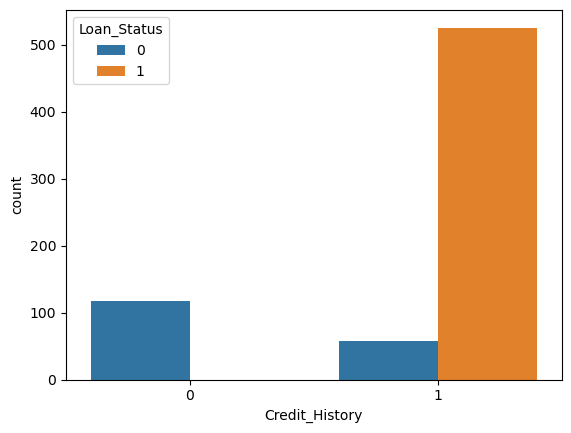

In [40]:
sns.countplot(x='Credit_History',hue='Loan_Status',data=data)
plt.show()

#### Applicants with credit history = 1 have a very high chance of loan approval, making it the most important feature.

In [41]:
data.groupby('Credit_History')['Loan_Status'].mean()

Credit_History
0    0.00000
1    0.90223
Name: Loan_Status, dtype: float64

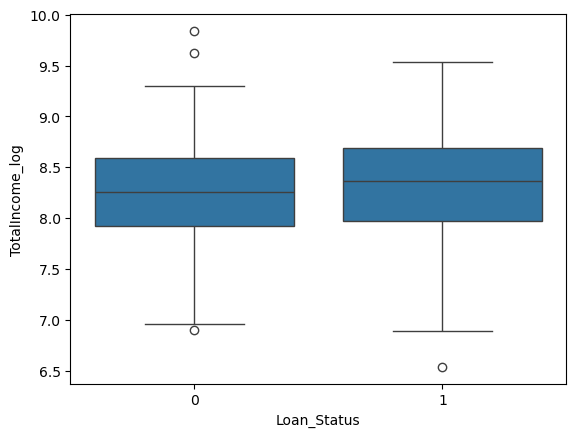

In [42]:
sns.boxplot(x='Loan_Status',y='TotalIncome_log',data=data)
plt.show()

#### Approved applicants tend to have slightly higher income, but the difference is not very strong.

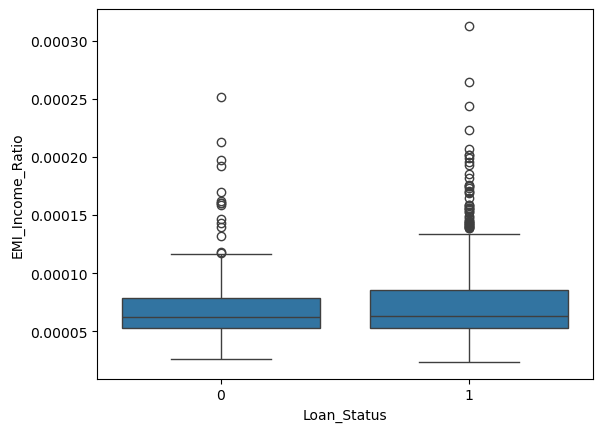

In [43]:
sns.boxplot(x='Loan_Status', y='EMI_Income_Ratio', data=data)
plt.show()

#### Higher EMI-to-income ratio slightly increases rejection chances, indicating repayment burden matters.

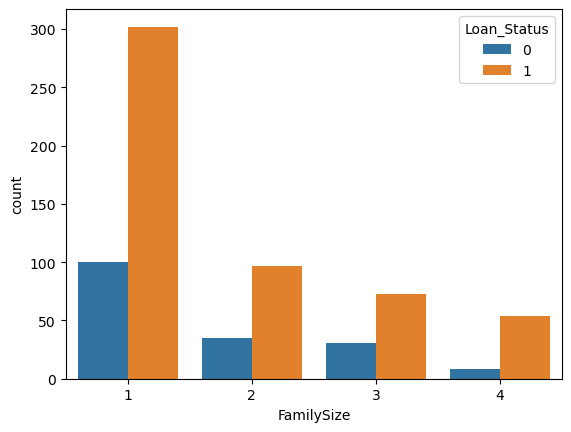

In [44]:
sns.countplot(x='FamilySize', hue='Loan_Status', data=data)
plt.show()

#### Smaller families have higher approval rates, possibly due to lower financial burden.

In [45]:
data.groupby('FamilySize')['Loan_Status'].mean()

FamilySize
1    0.751244
2    0.734848
3    0.701923
4    0.870968
Name: Loan_Status, dtype: float64

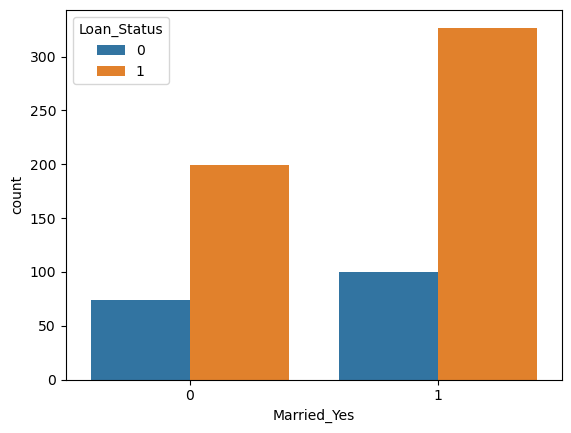

In [46]:
sns.countplot(x='Married_Yes', hue='Loan_Status', data=data)
plt.show()

#### Married applicants have a higher likelihood of loan approval.

In [47]:
data.groupby('Married_Yes')['Loan_Status'].mean()

Married_Yes
0    0.728938
1    0.765808
Name: Loan_Status, dtype: float64

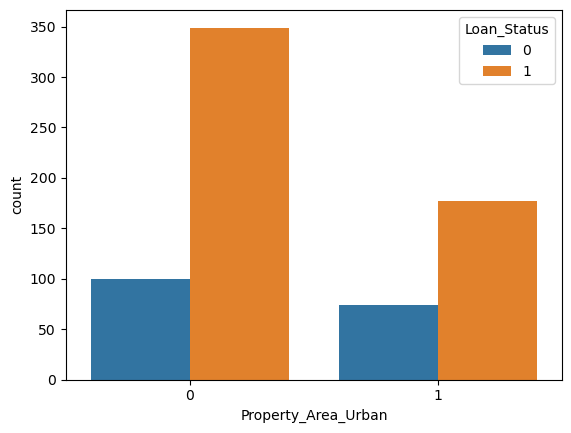

In [48]:
sns.countplot(x='Property_Area_Urban', hue='Loan_Status', data=data)
plt.show()

#### Applicants from semi-urban areas show higher loan approval rates compared to urban areas.

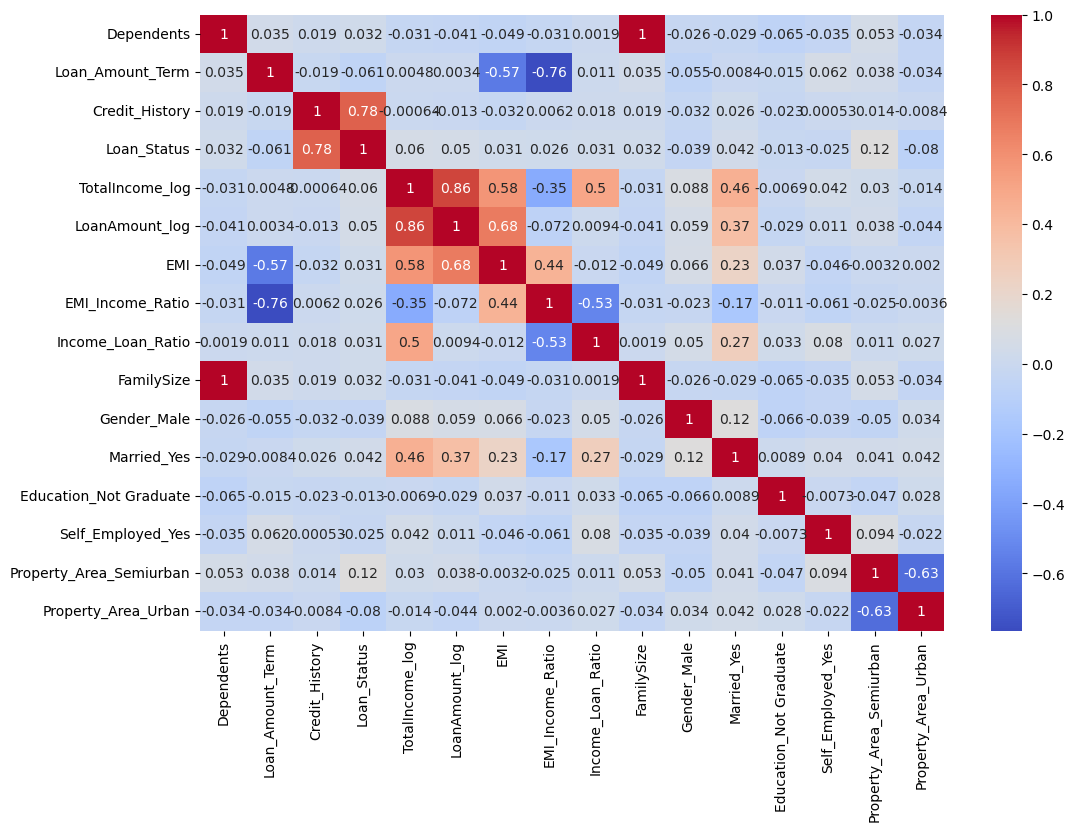

In [49]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

#### Credit history shows the strongest correlation with loan approval, while income-related features also contribute moderately.

### Logistic Regression

In [50]:
x = data.drop('Loan_Status',axis=1)
y = data['Loan_Status']

In [51]:
#Train-Test Split

In [52]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [53]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [54]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [55]:
y_pred = model.predict(x_test)

In [56]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9071428571428571


In [57]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 18  13]
 [  0 109]]


>- 109 applicants were approved and correctly predicted.
>- 18 applicants were rejected and correctly predicted.
>- 13 applicants were actually rejected but predicted as approved. 
>- 0 applicants were actually approved but predicted as rejected.

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.58      0.73        31
           1       0.89      1.00      0.94       109

    accuracy                           0.91       140
   macro avg       0.95      0.79      0.84       140
weighted avg       0.92      0.91      0.90       140



#### The model performs very well in identifying approved loans but has moderate performance in detecting rejected cases, which could lead to approving some risky applicants.

In [59]:
import joblib

joblib.dump(model, "loan_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(x.columns), "feature_columns.pkl")

print("Model, scaler, and feature columns saved successfully.")

Model, scaler, and feature columns saved successfully.
